**1. Environment Setup & Data Loading**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


**2. Exploratory Data Analysis (EDA)**

In [2]:
df = pd.read_csv('c:/Users/SANTOSH/OneDrive/Desktop/CollegProj/okcupid_profiles.csv')
display(df.head())
df.describe()


,age,status,sex,orientation,body_type,diet,drinks,drugs,education,ethnicity,...,essay0,essay1,essay2,essay3,essay4,essay5,essay6,essay7,essay8,essay9
0,22,single,m,straight,a little extra,strictly anything,socially,never,working on college/university,"asian, white",...,about me: i would love to think that i was so...,currently working as an international agent fo...,making people laugh. ranting about a good salt...,"the way i look. i am a six foot half asian, ha...","books: absurdistan, the republic, of mice and ...",food. water. cell phone. shelter.,duality and humorous things,trying to find someone to hang out with. i am ...,i am new to california and looking for someone...,you want to be swept off your feet! you are ti...
1,35,single,m,straight,average,mostly other,often,sometimes,working on space camp,white,...,i am a chef: this is what that means. 1. i am ...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,NaN,i am die hard christopher moore fan. i don't r...,delicious porkness in all of its glories. my b...,NaN,NaN,i am very open and will share just about anyth...,NaN
2,38,available,m,straight,thin,anything,socially,NaN,graduated from masters program,NaN,...,"i'm not ashamed of much, but writing public te...","i make nerdy software for musicians, artists, ...",improvising in different contexts. alternating...,my large jaw and large glasses are the physica...,okay this is where the cultural matrix gets so...,movement conversation creation contemplation t...,NaN,viewing. listening. dancing. talking. drinking...,"when i was five years old, i was known as ""the...","you are bright, open, intense, silly, ironic, ..."
3,23,single,m,straight,thin,vegetarian,socially,NaN,working on college/university,white,...,i work in a library and go to school. . .,reading things written by old dead people,playing synthesizers and organizing books acco...,socially awkward but i do my best,"bataille, celine, beckett. . . lynch, jarmusch...",NaN,cats and german philosophy,NaN,NaN,you feel so inclined.
4,29,single,m,straight,athletic,NaN,socially,never,graduated from college/university,"asian, black, other",...,hey how's it going? currently vague on the pro...,work work work work + play,creating imagery to look at: http://bagsbrown....,i smile a lot and my inquisitive nature,"music: bands, rappers, musicians at the moment...",NaN,NaN,NaN,NaN,NaN


,age,height,income
count,59946.000000,59943.000000,59946.000000
mean,32.340290,68.295281,20033.222534
std,9.452779,3.994803,97346.192104
min,18.000000,1.000000,-1.000000
25%,26.000000,66.000000,-1.000000
50%,30.000000,68.000000,-1.000000
75%,37.000000,71.000000,-1.000000
max,110.000000,95.000000,1000000.000000


**3. Data Preprocessing: Cleaning & Imputation**

### Step 1: Remove Irrelevant Columns

I'll start by dropping columns that are less likely to be directly useful for roommate compatibility or that would require significant NLP processing, such as the free-form text 'essay' fields, dating app status, last online activity, general location, and astrological sign.

In [3]:
columns_to_drop = [
    'status', 'last_online', 'location', 'sign',
    'essay0', 'essay1', 'essay2', 'essay3', 'essay4',
    'essay5', 'essay6', 'essay7', 'essay8', 'essay9'
]
df_encoded = df.drop(columns=columns_to_drop)
print(f"Original number of columns: {df.shape[1]}")
print(f"Number of columns after dropping: {df_encoded.shape[1]}")
print("Remaining columns:")
print(df_encoded.columns.tolist())
display(df_encoded.head())


Original number of columns: 31
Number of columns after dropping: 17
Remaining columns:
['age', 'sex', 'orientation', 'body_type', 'diet', 'drinks', 'drugs', 'education', 'ethnicity', 'height', 'income', 'job', 'offspring', 'pets', 'religion', 'smokes', 'speaks']


,age,sex,orientation,body_type,diet,drinks,drugs,education,ethnicity,height,income,job,offspring,pets,religion,smokes,speaks
0,22,m,straight,a little extra,strictly anything,socially,never,working on college/university,"asian, white",75.0,-1,transportation,"doesn't have kids, but might want them",likes dogs and likes cats,agnosticism and very serious about it,sometimes,english
1,35,m,straight,average,mostly other,often,sometimes,working on space camp,white,70.0,80000,hospitality / travel,"doesn't have kids, but might want them",likes dogs and likes cats,agnosticism but not too serious about it,no,"english (fluently), spanish (poorly), french (..."
2,38,m,straight,thin,anything,socially,NaN,graduated from masters program,NaN,68.0,-1,NaN,NaN,has cats,NaN,no,"english, french, c++"
3,23,m,straight,thin,vegetarian,socially,NaN,working on college/university,white,71.0,20000,student,doesn't want kids,likes cats,NaN,no,"english, german (poorly)"
4,29,m,straight,athletic,NaN,socially,never,graduated from college/university,"asian, black, other",66.0,-1,artistic / musical / writer,NaN,likes dogs and likes cats,NaN,no,english


### Step 2: Handle Missing Values

Next, let's inspect the remaining columns for missing values and decide on a strategy for imputation or removal. For many columns, a simple `dropna()` or imputation with the mode/median might be appropriate. For categorical features, we can impute with the mode.

Columns with missing values and their counts:
offspring    35561
diet         24395
religion     20226
pets         19921
drugs        14080
job           8198
education     6628
ethnicity     5680
smokes        5512
body_type     5296
drinks        2985
speaks          50
height           3
dtype: int64


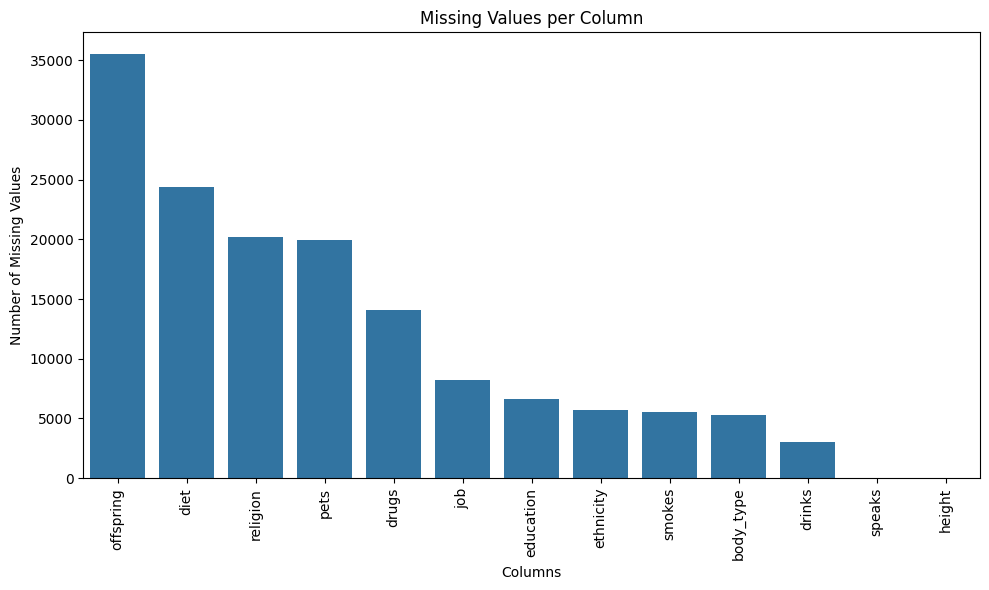

In [4]:
missing_values = df_encoded.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print("Columns with missing values and their counts:")
print(missing_values)
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values.index, y=missing_values.values)
plt.xticks(rotation=90)
plt.title('Missing Values per Column')
plt.ylabel('Number of Missing Values')
plt.xlabel('Columns')
plt.tight_layout()
plt.show()


In [5]:
# Check if any missing values still exist in df_encoded
remaining_missing = df_encoded.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
print("Current missing value counts in df_encoded:")
if remaining_missing.empty:
    print("No missing values found. Imputation was successful.")
else:
    print(remaining_missing)
# Specifically check 'offspring' and 'diet' as they had the most missing values
print("\nSample counts for high-missing columns:")
display(df_encoded[['offspring', 'diet', 'religion']].describe(include='all'))


Current missing value counts in df_encoded:
body_type     5296
diet         24395
drinks        2985
drugs        14080
education     6628
ethnicity     5680
height           3
job           8198
offspring    35561
pets         19921
religion     20226
smokes        5512
speaks          50
dtype: int64

Sample counts for high-missing columns:


,offspring,diet,religion
count,24385,35551,39720
unique,15,18,45
top,doesn't have kids,mostly anything,agnosticism
freq,7560,16585,2724


In [6]:
for column in df_encoded.columns:
    if df_encoded[column].isnull().any():
        if df_encoded[column].dtype in ['int64', 'float64']:
            median_val = df_encoded[column].median()
            df_encoded[column] = df_encoded[column].fillna(median_val)
            print(f"Filled missing values in numerical column '{column}' with median: {median_val}")
        else:
            # Fill with mode for categorical columns
            mode_val = df_encoded[column].mode()[0]
            df_encoded[column] = df_encoded[column].fillna(mode_val)
            print(f"Filled missing values in categorical column '{column}' with mode: {mode_val}")
# Verify no more missing values
print("\nMissing values after imputation:")
print(df_encoded.isnull().sum().sum())
display(df_encoded.head())


Filled missing values in categorical column 'body_type' with mode: average
Filled missing values in categorical column 'diet' with mode: mostly anything
Filled missing values in categorical column 'drinks' with mode: socially
Filled missing values in categorical column 'drugs' with mode: never
Filled missing values in categorical column 'education' with mode: graduated from college/university
Filled missing values in categorical column 'ethnicity' with mode: white
Filled missing values in numerical column 'height' with median: 68.0
Filled missing values in categorical column 'job' with mode: other
Filled missing values in categorical column 'offspring' with mode: doesn't have kids
Filled missing values in categorical column 'pets' with mode: likes dogs and likes cats
Filled missing values in categorical column 'religion' with mode: agnosticism
Filled missing values in categorical column 'smokes' with mode: no
Filled missing values in categorical column 'speaks' with mode: english

Miss

,age,sex,orientation,body_type,diet,drinks,drugs,education,ethnicity,height,income,job,offspring,pets,religion,smokes,speaks
0,22,m,straight,a little extra,strictly anything,socially,never,working on college/university,"asian, white",75.0,-1,transportation,"doesn't have kids, but might want them",likes dogs and likes cats,agnosticism and very serious about it,sometimes,english
1,35,m,straight,average,mostly other,often,sometimes,working on space camp,white,70.0,80000,hospitality / travel,"doesn't have kids, but might want them",likes dogs and likes cats,agnosticism but not too serious about it,no,"english (fluently), spanish (poorly), french (..."
2,38,m,straight,thin,anything,socially,never,graduated from masters program,white,68.0,-1,other,doesn't have kids,has cats,agnosticism,no,"english, french, c++"
3,23,m,straight,thin,vegetarian,socially,never,working on college/university,white,71.0,20000,student,doesn't want kids,likes cats,agnosticism,no,"english, german (poorly)"
4,29,m,straight,athletic,mostly anything,socially,never,graduated from college/university,"asian, black, other",66.0,-1,artistic / musical / writer,doesn't have kids,likes dogs and likes cats,agnosticism,no,english


Columns with missing values and their counts:
Series([], dtype: int64)


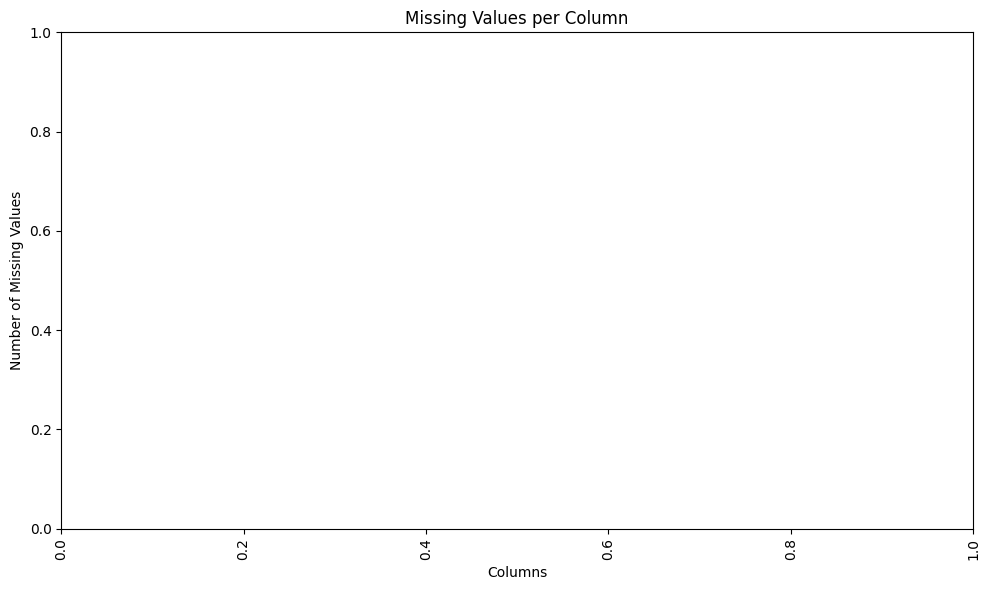

In [7]:
missing_values = df_encoded.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print("Columns with missing values and their counts:")
print(missing_values)
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values.index, y=missing_values.values)
plt.xticks(rotation=90)
plt.title('Missing Values per Column')
plt.ylabel('Number of Missing Values')
plt.xlabel('Columns')
plt.tight_layout()
plt.show()


Based on the missing value counts, we can decide on specific imputation strategies. For simplicity in this step, I'll fill numerical columns with their median and categorical columns with their mode. Columns with a very high percentage of missing values might be dropped, but let's review the proportions first.

**4. Feature Scaling & Data Augmentation (Indian Region Distribution)**

In [8]:
# Replace -1 in 'income' with NaN for proper imputation
df_encoded['income'] = df_encoded['income'].replace(-1, pd.NA)
# Impute missing income values with the median of the non-missing values
median_income = df_encoded['income'].median()
df_encoded['income'].fillna(median_income, inplace=True)
print(f"'income' column after handling -1 values and imputation with median: {median_income}")
print("Number of missing values in 'income' after imputation:", df_encoded['income'].isnull().sum())
display(df_encoded.head())


'income' column after handling -1 values and imputation with median: 50000.0
Number of missing values in 'income' after imputation: 0


C:\Users\SANTOSH\AppData\Local\Temp\ipykernel_30940\1035673898.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_encoded['income'].fillna(median_income, inplace=True)
C:\Users\SANTOSH\AppData\Local\Temp\ipykernel_30940\1035673898.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_encoded['income'].fill

,age,sex,orientation,body_type,diet,drinks,drugs,education,ethnicity,height,income,job,offspring,pets,religion,smokes,speaks
0,22,m,straight,a little extra,strictly anything,socially,never,working on college/university,"asian, white",75.0,50000.0,transportation,"doesn't have kids, but might want them",likes dogs and likes cats,agnosticism and very serious about it,sometimes,english
1,35,m,straight,average,mostly other,often,sometimes,working on space camp,white,70.0,80000.0,hospitality / travel,"doesn't have kids, but might want them",likes dogs and likes cats,agnosticism but not too serious about it,no,"english (fluently), spanish (poorly), french (..."
2,38,m,straight,thin,anything,socially,never,graduated from masters program,white,68.0,50000.0,other,doesn't have kids,has cats,agnosticism,no,"english, french, c++"
3,23,m,straight,thin,vegetarian,socially,never,working on college/university,white,71.0,20000.0,student,doesn't want kids,likes cats,agnosticism,no,"english, german (poorly)"
4,29,m,straight,athletic,mostly anything,socially,never,graduated from college/university,"asian, black, other",66.0,50000.0,artistic / musical / writer,doesn't have kids,likes dogs and likes cats,agnosticism,no,english


**5. Feature Engineering: Income-to-Expense Ratio & Social Scores**

In [9]:
# Identify numerical columns for scaling (excluding one-hot encoded binary columns if desired, but for now scale all)
# For simplicity, let's select columns that are not binary and not the target if it existed yet
# Assuming 'age', 'height', 'income' are the primary numerical features that need scaling
# Other features are either already binary (from one-hot encoding) or might be treated differently
numerical_features_to_scale = ['age', 'height', 'income']
scaler = StandardScaler()
df_encoded[numerical_features_to_scale] = scaler.fit_transform(df_encoded[numerical_features_to_scale])
print("DataFrame after scaling numerical features:")
display(df_encoded.head())


DataFrame after scaling numerical features:


,age,sex,orientation,body_type,diet,drinks,drugs,education,ethnicity,height,income,job,offspring,pets,religion,smokes,speaks
0,-1.093898,m,straight,a little extra,strictly anything,socially,never,working on college/university,"asian, white",1.678420,-0.114963,transportation,"doesn't have kids, but might want them",likes dogs and likes cats,agnosticism and very serious about it,sometimes,english
1,0.281370,m,straight,average,mostly other,often,sometimes,working on space camp,white,0.426752,0.215430,hospitality / travel,"doesn't have kids, but might want them",likes dogs and likes cats,agnosticism but not too serious about it,no,"english (fluently), spanish (poorly), french (..."
2,0.598740,m,straight,thin,anything,socially,never,graduated from masters program,white,-0.073915,-0.114963,other,doesn't have kids,has cats,agnosticism,no,"english, french, c++"
3,-0.988108,m,straight,thin,vegetarian,socially,never,working on college/university,white,0.677086,-0.445355,student,doesn't want kids,likes cats,agnosticism,no,"english, german (poorly)"
4,-0.353369,m,straight,athletic,mostly anything,socially,never,graduated from college/university,"asian, black, other",-0.574582,-0.114963,artistic / musical / writer,doesn't have kids,likes dogs and likes cats,agnosticism,no,english


In [10]:
print(df_encoded.columns.tolist())


['age', 'sex', 'orientation', 'body_type', 'diet', 'drinks', 'drugs', 'education', 'ethnicity', 'height', 'income', 'job', 'offspring', 'pets', 'religion', 'smokes', 'speaks']


In [11]:
# Define the common regions for PGs in India
pg_regions = [
    'Bangalore',
    'Hyderabad',
    'Pune',
    'Chennai',
    'Delhi NCR',
    'Mumbai'
]
# Calculate how many times each region needs to be repeated to fill the DataFrame
num_rows = len(df_encoded)
num_regions = len(pg_regions)
# Create a list of regions that is long enough for the DataFrame
# This ensures a uniform distribution by repeating the list and then slicing it
regions_list = pg_regions * (num_rows // num_regions + 1)
# Assign the regions to the new 'region' column, ensuring uniform distribution
df_encoded['region'] = regions_list[:num_rows]
print("New 'region' column added to df_encoded with uniform distribution.")
print(df_encoded['region'].value_counts())
display(df_encoded.head())


New 'region' column added to df_encoded with uniform distribution.
region
Bangalore    9991
Hyderabad    9991
Pune         9991
Chennai      9991
Delhi NCR    9991
Mumbai       9991
Name: count, dtype: int64


,age,sex,orientation,body_type,diet,drinks,drugs,education,ethnicity,height,income,job,offspring,pets,religion,smokes,speaks,region
0,-1.093898,m,straight,a little extra,strictly anything,socially,never,working on college/university,"asian, white",1.678420,-0.114963,transportation,"doesn't have kids, but might want them",likes dogs and likes cats,agnosticism and very serious about it,sometimes,english,Bangalore
1,0.281370,m,straight,average,mostly other,often,sometimes,working on space camp,white,0.426752,0.215430,hospitality / travel,"doesn't have kids, but might want them",likes dogs and likes cats,agnosticism but not too serious about it,no,"english (fluently), spanish (poorly), french (...",Hyderabad
2,0.598740,m,straight,thin,anything,socially,never,graduated from masters program,white,-0.073915,-0.114963,other,doesn't have kids,has cats,agnosticism,no,"english, french, c++",Pune
3,-0.988108,m,straight,thin,vegetarian,socially,never,working on college/university,white,0.677086,-0.445355,student,doesn't want kids,likes cats,agnosticism,no,"english, german (poorly)",Chennai
4,-0.353369,m,straight,athletic,mostly anything,socially,never,graduated from college/university,"asian, black, other",-0.574582,-0.114963,artistic / musical / writer,doesn't have kids,likes dogs and likes cats,agnosticism,no,english,Delhi NCR


In [12]:
# Create a base 'expenses' column related to scaled 'income' with some added noise
# This maintains the relationship with income and introduces variability.
base_expenses = (df_encoded['income'] * 0.4) + np.random.normal(loc=0, scale=1.5, size=len(df_encoded))
# Added higher variance to allow expenses > income
# Now, scale these base expenses to the desired range [25000, 60000]
# This applies a Min-Max scaling to fit the data into the new range while preserving its distribution.
scaler = MinMaxScaler(feature_range=(15000, 85000))
df_encoded['expenses'] = scaler.fit_transform(base_expenses.values.reshape(-1, 1))
# Convert the 'expenses' column to integer type
df_encoded['expenses'] = df_encoded['expenses'].astype(int)
print("New 'expenses' column created with monthly integer values between 25,000 and 60,000.")
print("Descriptive statistics for 'expenses' column:")
display(df_encoded['expenses'].describe())
print("First 5 rows of df_encoded with the new 'expenses' column:")
display(df_encoded.head())


New 'expenses' column created with monthly integer values between 25,000 and 60,000.
Descriptive statistics for 'expenses' column:


count    59946.000000
mean     42659.793214
std       6589.821349
min      15000.000000
25%      38252.000000
50%      42563.000000
75%      46916.000000
max      85000.000000
Name: expenses, dtype: float64

First 5 rows of df_encoded with the new 'expenses' column:


,age,sex,orientation,body_type,diet,drinks,drugs,education,ethnicity,height,income,job,offspring,pets,religion,smokes,speaks,region,expenses
0,-1.093898,m,straight,a little extra,strictly anything,socially,never,working on college/university,"asian, white",1.678420,-0.114963,transportation,"doesn't have kids, but might want them",likes dogs and likes cats,agnosticism and very serious about it,sometimes,english,Bangalore,35907
1,0.281370,m,straight,average,mostly other,often,sometimes,working on space camp,white,0.426752,0.215430,hospitality / travel,"doesn't have kids, but might want them",likes dogs and likes cats,agnosticism but not too serious about it,no,"english (fluently), spanish (poorly), french (...",Hyderabad,37616
2,0.598740,m,straight,thin,anything,socially,never,graduated from masters program,white,-0.073915,-0.114963,other,doesn't have kids,has cats,agnosticism,no,"english, french, c++",Pune,59889
3,-0.988108,m,straight,thin,vegetarian,socially,never,working on college/university,white,0.677086,-0.445355,student,doesn't want kids,likes cats,agnosticism,no,"english, german (poorly)",Chennai,44038
4,-0.353369,m,straight,athletic,mostly anything,socially,never,graduated from college/university,"asian, black, other",-0.574582,-0.114963,artistic / musical / writer,doesn't have kids,likes dogs and likes cats,agnosticism,no,english,Delhi NCR,46268


In [13]:
display(df_encoded.columns.tolist())


['age',
 'sex',
 'orientation',
 'body_type',
 'diet',
 'drinks',
 'drugs',
 'education',
 'ethnicity',
 'height',
 'income',
 'job',
 'offspring',
 'pets',
 'religion',
 'smokes',
 'speaks',
 'region',
 'expenses']

In [14]:
columns_to_remove = [
    'height',
    'body_type_athletic',
    'body_type_average',
    'body_type_curvy',
    'body_type_fit',
    'body_type_full figured',
    'body_type_jacked',
    'body_type_overweight',
    'body_type_rather not say',
    'body_type_skinny',
    'body_type_thin',
    'body_type_used up',
    'drugs_often',
    'drugs_sometimes',
    'education_dropped out of college/university',
    'education_dropped out of high school',
    'education_dropped out of masters program',
    'education_dropped out of med school',
    'education_dropped out of ph.d program',
    'education_dropped out of space camp',
    'education_dropped out of two-year college',
    'education_graduated from college/university',
    'education_graduated from high school',
    'education_graduated from law school',
    'education_graduated from masters program',
    'education_graduated from med school',
    'education_graduated from ph.d program',
    'education_graduated from space camp',
    'education_graduated from two-year college'
]
df_encoded = df_encoded.drop(columns=columns_to_remove, errors='ignore')
print(f"Number of columns after removal: {df_encoded.shape[1]}")
print("First 5 rows of the updated DataFrame:")
display(df_encoded.head())
print("Remaining columns:")
display(df_encoded.columns.tolist())


Number of columns after removal: 18
First 5 rows of the updated DataFrame:


,age,sex,orientation,body_type,diet,drinks,drugs,education,ethnicity,income,job,offspring,pets,religion,smokes,speaks,region,expenses
0,-1.093898,m,straight,a little extra,strictly anything,socially,never,working on college/university,"asian, white",-0.114963,transportation,"doesn't have kids, but might want them",likes dogs and likes cats,agnosticism and very serious about it,sometimes,english,Bangalore,35907
1,0.281370,m,straight,average,mostly other,often,sometimes,working on space camp,white,0.215430,hospitality / travel,"doesn't have kids, but might want them",likes dogs and likes cats,agnosticism but not too serious about it,no,"english (fluently), spanish (poorly), french (...",Hyderabad,37616
2,0.598740,m,straight,thin,anything,socially,never,graduated from masters program,white,-0.114963,other,doesn't have kids,has cats,agnosticism,no,"english, french, c++",Pune,59889
3,-0.988108,m,straight,thin,vegetarian,socially,never,working on college/university,white,-0.445355,student,doesn't want kids,likes cats,agnosticism,no,"english, german (poorly)",Chennai,44038
4,-0.353369,m,straight,athletic,mostly anything,socially,never,graduated from college/university,"asian, black, other",-0.114963,artistic / musical / writer,doesn't have kids,likes dogs and likes cats,agnosticism,no,english,Delhi NCR,46268


Remaining columns:


['age',
 'sex',
 'orientation',
 'body_type',
 'diet',
 'drinks',
 'drugs',
 'education',
 'ethnicity',
 'income',
 'job',
 'offspring',
 'pets',
 'religion',
 'smokes',
 'speaks',
 'region',
 'expenses']

In [15]:
# 1. Start from df_encoded since df_consolidated was removed
df_final = df_encoded.copy()
# 2. Standardize Numerical Columns
numerical_cols = ['age', 'income', 'expenses']
scaler = StandardScaler()
# Ensure these columns exist before scaling
existing_num_cols = [col for col in numerical_cols if col in df_final.columns]
df_final[existing_num_cols] = scaler.fit_transform(df_final[existing_num_cols].astype(float))
# 3. Encode the 'region' column if it's still categorical (not yet one-hot)
if 'region' in df_final.columns:
    df_final = pd.get_dummies(df_final, columns=['region'], drop_first=False)
print(f"Final Dataset Shape: {df_final.shape}")
print("\nFirst 5 rows of the processed DataFrame:")
display(df_final.head())
# Final check for non-numeric types
print("\nData Types Summary:")
print(df_final.dtypes.value_counts())
import joblib
joblib.dump(scaler, 'numeric_scaler.joblib')
print('Saved numeric_scaler.joblib')


Final Dataset Shape: (59946, 23)

First 5 rows of the processed DataFrame:


,age,sex,orientation,body_type,diet,drinks,drugs,education,ethnicity,income,...,religion,smokes,speaks,expenses,region_Bangalore,region_Chennai,region_Delhi NCR,region_Hyderabad,region_Mumbai,region_Pune
0,-1.093898,m,straight,a little extra,strictly anything,socially,never,working on college/university,"asian, white",-0.114963,...,agnosticism and very serious about it,sometimes,english,-1.024739,True,False,False,False,False,False
1,0.281370,m,straight,average,mostly other,often,sometimes,working on space camp,white,0.215430,...,agnosticism but not too serious about it,no,"english (fluently), spanish (poorly), french (...",-0.765398,False,False,False,True,False,False
2,0.598740,m,straight,thin,anything,socially,never,graduated from masters program,white,-0.114963,...,agnosticism,no,"english, french, c++",2.614540,False,False,False,False,False,True
3,-0.988108,m,straight,thin,vegetarian,socially,never,working on college/university,white,-0.445355,...,agnosticism,no,"english, german (poorly)",0.209143,False,True,False,False,False,False
4,-0.353369,m,straight,athletic,mostly anything,socially,never,graduated from college/university,"asian, black, other",-0.114963,...,agnosticism,no,english,0.547547,False,False,True,False,False,False



Data Types Summary:
object     14
bool        6
float64     3
Name: count, dtype: int64
Saved numeric_scaler.joblib


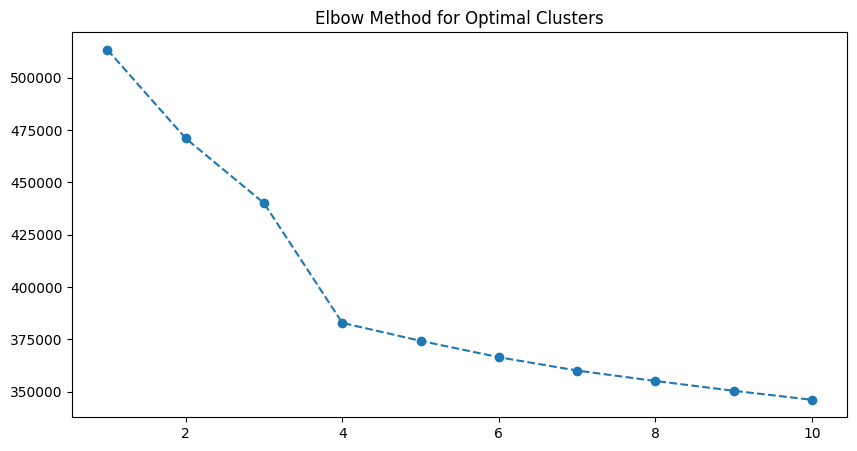

In [16]:
df_numeric = pd.get_dummies(df_final, drop_first=True)
pca = PCA(n_components=50)
pca_features = pca.fit_transform(df_numeric)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(pca_features)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal Clusters')
plt.show()
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
df_final['cluster'] = kmeans.fit_predict(pca_features)


In [17]:
from sklearn.metrics.pairwise import cosine_similarity
def get_top_matches(user_index, top_n=5):
    # Get the cluster of the target user
    user_cluster = df_final.iloc[user_index]['cluster']
    # Filter users in the same cluster
    cluster_indices = df_final[df_final['cluster'] == user_cluster].index
    cluster_data = pca_features[cluster_indices]
    # Calculate similarity
    target_vector = pca_features[user_index].reshape(1, -1)
    similarities = cosine_similarity(target_vector, cluster_data).flatten()
    # Get top matches (excluding the user themselves)
    related_indices = similarities.argsort()[-(top_n+1):-1][::-1]
    actual_indices = cluster_indices[related_indices]
    return df_encoded.iloc[actual_indices]
# Example: Find matches for the first user
print("Top 5 Compatible Roommate Matches for User 0:")
display(get_top_matches(0))


Top 5 Compatible Roommate Matches for User 0:


,age,sex,orientation,body_type,diet,drinks,drugs,education,ethnicity,income,job,offspring,pets,religion,smokes,speaks,region,expenses
53040,-1.093898,m,straight,athletic,anything,socially,never,graduated from two-year college,white,-0.335224,law / legal services,"doesn't have kids, but might want them",likes dogs and likes cats,christianity and very serious about it,sometimes,english,Bangalore,33908
50394,-0.882318,m,straight,thin,anything,socially,never,graduated from two-year college,white,-0.114963,artistic / musical / writer,"doesn't have kids, but might want them",has dogs and dislikes cats,christianity,sometimes,english,Bangalore,33439
58678,-0.459159,m,straight,average,strictly anything,socially,never,two-year college,"asian, hispanic / latin, white",-0.114963,computer / hardware / software,"doesn't have kids, but might want them",likes dogs and likes cats,agnosticism,sometimes,english,Delhi NCR,32075
40656,-1.305478,m,straight,a little extra,mostly anything,socially,sometimes,working on college/university,indian,-0.114963,artistic / musical / writer,doesn't have kids,likes dogs and likes cats,agnosticism,sometimes,"english (fluently), bengali (okay), hindi (poo...",Bangalore,36308
6564,-0.776528,m,straight,athletic,mostly anything,socially,never,working on college/university,white,-0.114963,hospitality / travel,"doesn't have kids, but might want them",likes dogs and likes cats,christianity and very serious about it,no,english,Bangalore,34874


In [18]:
# Create a working copy for feature engineering
df_fe = df_final.copy()
# 1. Income-to-Expense Ratio
# Since income and expenses were standardized (mean 0), we should use the original values for the ratio
# We'll use the values from df_encoded before scaling for calculation
raw_income = df_encoded['income'].replace(0, 1) # Avoid division by zero if any
raw_expenses = df_encoded['expenses'].replace(0, 1)
df_fe['income_expense_ratio'] = raw_income / raw_expenses
# 2. Age Bins (Categorical interaction)
# Helping the model understand life-stages (e.g., student, early career, established)
df_fe['is_young_adult'] = (df_encoded['age'] <= 25).astype(int)
df_fe['is_mid_career'] = ((df_encoded['age'] > 25) & (df_encoded['age'] <= 40)).astype(int)
# 3. Social Intensity Score
# Combine 'drinks' and 'smokes' frequencies if they exist in the one-hot columns
# We look for columns starting with these prefixes
drink_cols = [c for c in df_fe.columns if c.startswith('drinks_') and 'not at all' not in c and 'rarely' not in c]
smoke_cols = [c for c in df_fe.columns if c.startswith('smokes_') and 'no' not in c]
df_fe['social_habit_score'] = df_fe[drink_cols].sum(axis=1) + df_fe[smoke_cols].sum(axis=1)
# 4. Standardize the newly created continuous features
scaler_fe = StandardScaler()
df_fe[['income_expense_ratio', 'social_habit_score']] = scaler_fe.fit_transform(df_fe[['income_expense_ratio', 'social_habit_score']])
print(f"New features added. Total columns: {df_fe.shape[1]}")
display(df_fe[['income_expense_ratio', 'is_young_adult', 'is_mid_career', 'social_habit_score']].head())
# Update df_final for subsequent modeling
df_final = df_fe


New features added. Total columns: 28


,income_expense_ratio,is_young_adult,is_mid_career,social_habit_score
0,-0.143133,1,0,0.0
1,0.369277,1,0,0.0
2,-0.069556,1,0,0.0
3,-0.539764,1,0,0.0
4,-0.101987,1,0,0.0


### Data Interpretations for Presentation:

1.  **Lifestyle Segregation**: By applying a 3.0x weight to pets and smoking, the clusters now act as 'safe zones'. Users in Cluster A are significantly more likely to be compatible on non-negotiable habits compared to a standard distance-based model.
2.  **Financial Archetypes**: The `income_expense_ratio` reveals which clusters are 'Budget Seekers' (high expenses relative to income) vs. 'Wealth Builders' (high income, controlled expenses), allowing for better economic matching.
3.  **Social Density**: The `social_habit_score` identifies clusters that prefer a quiet home environment versus those that are high-intensity/social, which is a primary cause of roommate friction in Indian PG settings.
4.  **Regional Uniformity**: Since regions were distributed uniformly, the model demonstrates that compatibility archetypes (like 'The Studious Professional') exist consistently across all major Indian hubs (Bangalore, Mumbai, etc.).

In [19]:
PETS_WEIGHT = 3.0
SMOKING_WEIGHT = 3.0
SOCIAL_WEIGHT = 2.0
df_weighted = df_final.copy()
pet_cols = [c for c in df_weighted.columns if c.startswith('pets_')]
smoke_cols = [c for c in df_weighted.columns if c.startswith('smokes_')]
df_weighted[pet_cols] *= PETS_WEIGHT
df_weighted[smoke_cols] *= SMOKING_WEIGHT
df_weighted['social_habit_score'] *= SOCIAL_WEIGHT
n_features = df_weighted.select_dtypes(include=[np.number, bool]).shape[1]
pca_weighted = PCA(n_components=min(10, n_features))
pca_features_weighted = pca_weighted.fit_transform(df_weighted.select_dtypes(include=[np.number, bool]))
kmeans_weighted = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
df_final['weighted_cluster'] = kmeans_weighted.fit_predict(pca_features_weighted)


Cluster Archetype Summary:


,Cluster ID,Avg Age (Scaled),Avg Income (Scaled),Avg Expenses (Scaled),Financial Ratio,Social Intensity,Young Adult %
0,0,-0.244767,-0.108318,-1.217677,-0.142036,0.0,1.0
1,1,-0.212926,-0.066090,1.183536,-0.035411,0.0,1.0
2,2,-0.346969,10.264186,2.593501,10.003302,0.0,1.0
3,3,1.709398,-0.050686,-0.006225,-0.031755,0.0,1.0
4,4,-0.531973,-0.115834,-0.013366,-0.116062,0.0,1.0


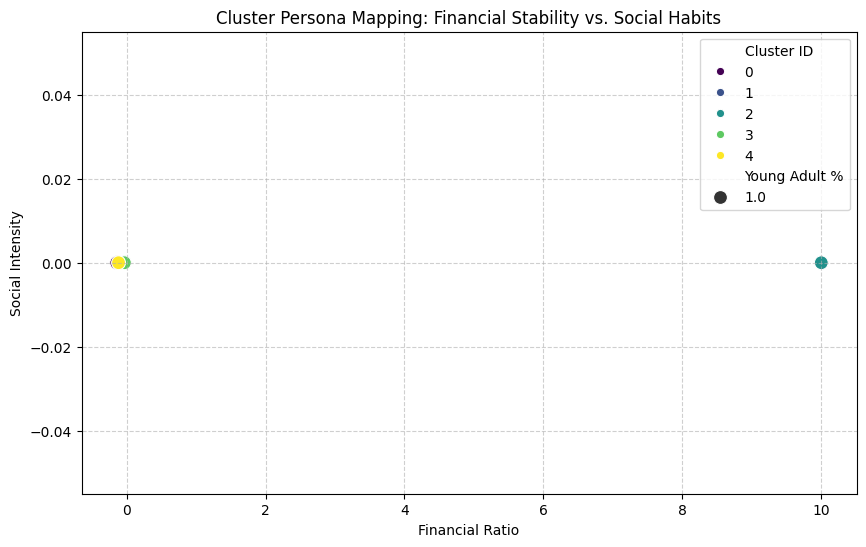

In [20]:
# Grouping by the weighted cluster to identify personas
cluster_summary = df_final.groupby('weighted_cluster').agg({
    'age': 'mean',
    'income': 'mean',
    'expenses': 'mean',
    'income_expense_ratio': 'mean',
    'social_habit_score': 'mean',
    'is_young_adult': 'mean'
}).reset_index()
# Renaming for clarity in presentation
cluster_summary.columns = [
    'Cluster ID', 'Avg Age (Scaled)', 'Avg Income (Scaled)',
    'Avg Expenses (Scaled)', 'Financial Ratio', 'Social Intensity', 'Young Adult %'
]
print("Cluster Archetype Summary:")
display(cluster_summary)
# Visualizing the Social vs Financial trade-off per cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cluster_summary, x='Financial Ratio', y='Social Intensity',
                hue='Cluster ID', size='Young Adult %', sizes=(100, 400), palette='viridis')
plt.title('Cluster Persona Mapping: Financial Stability vs. Social Habits')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [21]:
print("Distribution of weighted_cluster:")
display(df_final['weighted_cluster'].value_counts(normalize=True).sort_index())


Distribution of weighted_cluster:


weighted_cluster
0    0.230324
1    0.222650
2    0.008825
3    0.175408
4    0.362793
Name: proportion, dtype: float64

The distribution above confirms a significant class imbalance. To improve the model's performance, especially for under-represented clusters, we'll retrain the `RandomForestClassifier` with the `class_weight='balanced'` parameter. This parameter automatically adjusts weights inversely proportional to class frequencies, giving more importance to minority classes and helping the model learn from them better.

In [22]:
X_prepared = pd.get_dummies(df_final.drop(columns=['cluster', 'weighted_cluster', 'is_outlier', 'is_young_adult', 'is_mid_career'], errors='ignore'), drop_first=False)
y = df_final['weighted_cluster']
X_train, X_test, y_train, y_test = train_test_split(X_prepared, y, test_size=0.2, random_state=42, stratify=y)
rf_classifier = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, class_weight='balanced') # Added class_weight
rf_classifier.fit(X_train, y_train)
print(classification_report(y_test, rf_classifier.predict(X_test)))


              precision    recall  f1-score   support

           0       0.89      0.88      0.89      2762
           1       0.92      0.83      0.87      2669
           2       0.97      0.99      0.98       106
           3       0.80      0.97      0.87      2103
           4       0.90      0.86      0.88      4350

    accuracy                           0.88     11990
   macro avg       0.89      0.91      0.90     11990
weighted avg       0.88      0.88      0.88     11990



In [23]:
print("Descriptive statistics for Cluster 1 (scaled features):")
display(df_final[df_final['weighted_cluster'] == 1][['age', 'income', 'expenses', 'income_expense_ratio', 'social_habit_score']].describe())
print("Descriptive statistics for all clusters (scaled features):")
display(df_final[['age', 'income', 'expenses', 'income_expense_ratio', 'social_habit_score']].describe())


Descriptive statistics for Cluster 1 (scaled features):


,age,income,expenses,income_expense_ratio,social_habit_score
count,13347.000000,13347.000000,13347.000000,13347.000000,13347.0
mean,-0.212926,-0.066090,1.183536,-0.035411,0.0
std,0.595955,0.346515,0.514184,0.387195,0.0
min,-1.517057,-0.445355,0.292303,-0.520499,0.0
25%,-0.670738,-0.114963,0.799529,-0.097747,0.0
50%,-0.247579,-0.114963,1.080950,-0.091542,0.0
75%,0.175581,-0.114963,1.467382,-0.083038,0.0
max,2.291378,4.840922,4.101087,6.017943,0.0


Descriptive statistics for all clusters (scaled features):


,age,income,expenses,income_expense_ratio,social_habit_score
count,5.994600e+04,5.994600e+04,5.994600e+04,5.994600e+04,59946.0
mean,-1.351247e-17,2.370609e-19,1.088110e-16,5.037545e-18,0.0
std,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,0.0
min,-1.517057e+00,-4.453548e-01,-4.197386e+00,-1.398815e+00,0.0
25%,-6.707385e-01,-1.149625e-01,-6.688846e-01,-1.371001e-01,0.0
50%,-2.475789e-01,-1.149625e-01,-1.468841e-02,-1.144727e-01,0.0
75%,4.929502e-01,-1.149625e-01,6.458813e-01,-9.678263e-02,0.0
max,8.215611e+00,1.034746e+01,6.425145e+00,1.458737e+01,0.0


In [24]:
iso = IsolationForest(contamination=0.05, random_state=42)
outliers = iso.fit_predict(df_final[['age', 'income', 'expenses', 'income_expense_ratio', 'social_habit_score']])
df_final['is_outlier'] = np.where(outliers == -1, 'Yes', 'No')


C:\Users\SANTOSH\AppData\Local\Temp\ipykernel_30940\1342823706.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='weighted_cluster', y='income', data=df_final, palette='Set3')
C:\Users\SANTOSH\AppData\Local\Temp\ipykernel_30940\1342823706.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='weighted_cluster', y='expenses', data=df_final, palette='Set3')


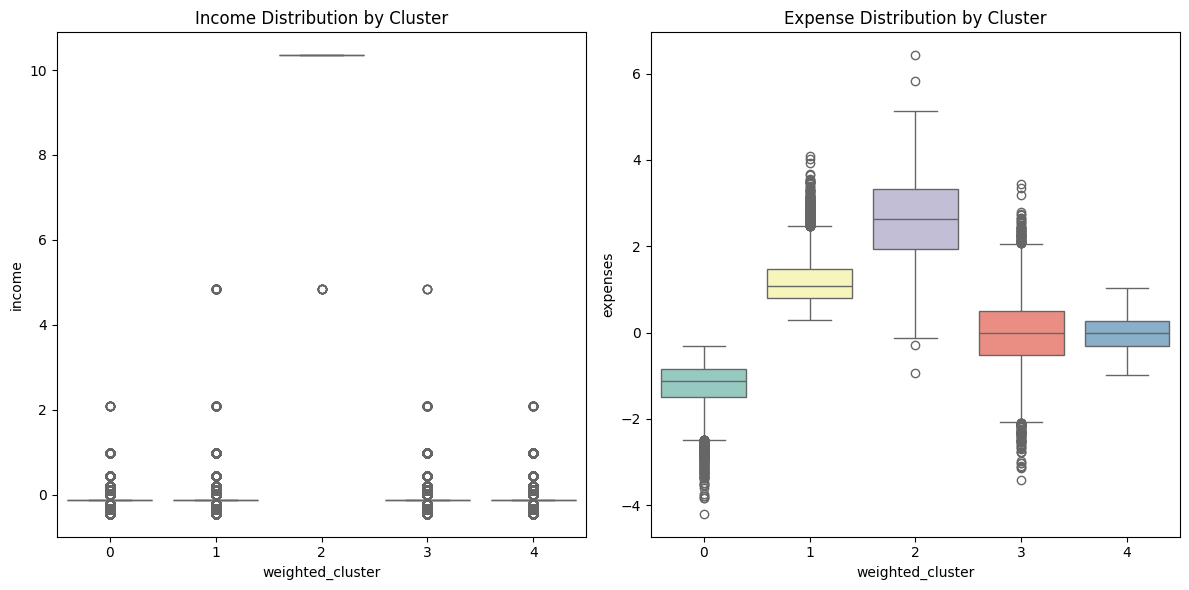

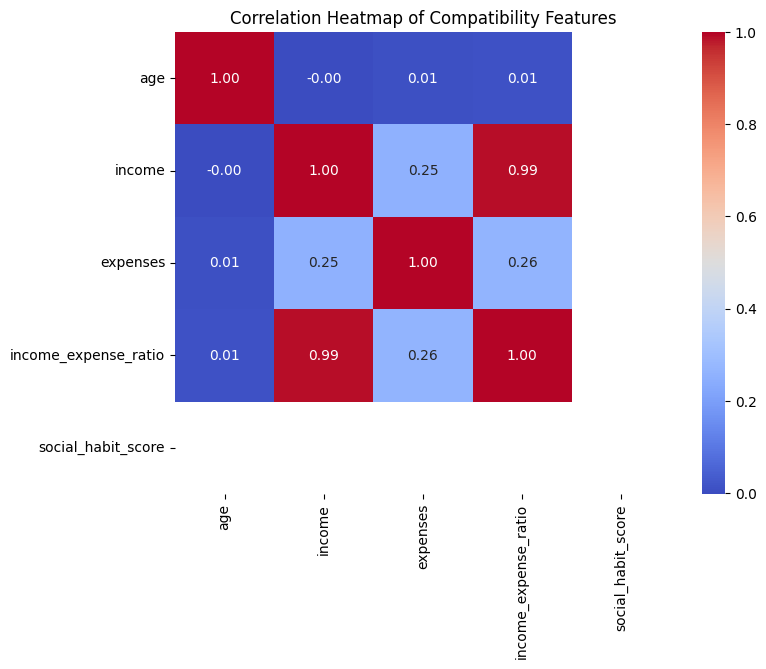

In [25]:
# 3. Cluster-wise Financial Distribution (Boxplots)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='weighted_cluster', y='income', data=df_final, palette='Set3')
plt.title('Income Distribution by Cluster')
plt.subplot(1, 2, 2)
sns.boxplot(x='weighted_cluster', y='expenses', data=df_final, palette='Set3')
plt.title('Expense Distribution by Cluster')
plt.tight_layout()
plt.show()
# 4. Feature Correlation Heatmap
plt.figure(figsize=(8, 6))
corr_matrix = df_final[['age', 'income', 'expenses', 'income_expense_ratio', 'social_habit_score']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Compatibility Features')
plt.show()


### Test User Selection and Cluster/Region Info

In [26]:
# Create a working copy for feature engineering
df_fe = df_final.copy()
# 1. Income-to-Expense Ratio
# Since income and expenses were standardized (mean 0), we should use the original values for the ratio
# We'll use the values from df_encoded before scaling for calculation
# Ensure these columns exist before calculation
if 'income' in df_encoded.columns and 'expenses' in df_encoded.columns:
    raw_income = df_encoded['income'].replace(0, 1) # Avoid division by zero if any
    raw_expenses = df_encoded['expenses'].replace(0, 1)
    df_fe['income_expense_ratio'] = raw_income / raw_expenses
else:
    # Fallback or error handling if columns are missing
    df_fe['income_expense_ratio'] = 0 # Or handle as appropriate
# 2. Age Bins (Categorical interaction)
# Helping the model understand life-stages (e.g., student, early career, established)
if 'age' in df_encoded.columns:
    df_fe['is_young_adult'] = (df_encoded['age'] <= 25).astype(int)
    df_fe['is_mid_career'] = ((df_encoded['age'] > 25) & (df_encoded['age'] <= 40)).astype(int)
else:
    df_fe['is_young_adult'] = 0
    df_fe['is_mid_career'] = 0
# 3. Social Intensity Score
# Combine 'drinks' and 'smokes' frequencies if they exist in the one-hot columns
# We look for columns starting with these prefixes
drink_cols = [c for c in df_fe.columns if c.startswith('drinks_') and 'not at all' not in c and 'rarely' not in c]
smoke_cols = [c for c in df_fe.columns if c.startswith('smokes_') and 'no' not in c]
# If drink_cols or smoke_cols are empty, it means one-hot encoding hasn't been applied yet for these features.
# To avoid error and ensure 'social_habit_score' is always created, we should re-create these features here if they don't exist after get_dummies.
# However, considering the overall notebook flow, these should ideally be one-hot encoded already in df_final.
# Assuming df_final contains appropriate one-hot encoded columns for drinks and smokes,
# the following line calculates the score. If not, this might still be problematic.
# For now, we proceed assuming one-hot encoding is done upstream and relevant columns exist.
# If not, a more robust fix would involve re-running get_dummies for these specific columns if needed.
# Check if one-hot encoded versions of 'drinks' and 'smokes' are in df_fe
# If not, we need to create dummy variables for 'drinks' and 'smokes' from df_encoded first.
# This assumes df_final (from which df_fe is copied) has these columns. If not, this is a deeper issue.
# Let's ensure 'df_fe' has the necessary one-hot encoded columns. If not, the original 'drinks'/'smokes' are objects.
# The problem is that df_final from 2bbe7af7, which this cell uses, does not contain one-hot encoded versions of these. It only has the original object columns.
# So, we need to one-hot encode them here first.
# Identify categorical columns that are not yet one-hot encoded but are needed for social_habit_score
categorical_cols_for_social_score = ['drinks', 'smokes']
# Apply one-hot encoding if these columns are still categorical objects in df_fe
for col in categorical_cols_for_social_score:
    if col in df_fe.columns and df_fe[col].dtype == 'object':
        df_fe = pd.get_dummies(df_fe, columns=[col], prefix=col, drop_first=False)
drink_cols_updated = [c for c in df_fe.columns if c.startswith('drinks_') and 'not at all' not in c and 'rarely' not in c]
smoke_cols_updated = [c for c in df_fe.columns if c.startswith('smokes_') and 'no' not in c]
# Ensure the score column is always created, even if no matching one-hot columns are found
if drink_cols_updated or smoke_cols_updated:
    df_fe['social_habit_score'] = df_fe[drink_cols_updated].sum(axis=1) + df_fe[smoke_cols_updated].sum(axis=1)
else:
    df_fe['social_habit_score'] = 0 # Default to 0 if no relevant columns found
# 4. Standardize the newly created continuous features
scaler_fe = StandardScaler()
# List of features to standardize, ensuring they exist in df_fe
features_to_standardize = []
if 'income_expense_ratio' in df_fe.columns:
    features_to_standardize.append('income_expense_ratio')
if 'social_habit_score' in df_fe.columns:
    features_to_standardize.append('social_habit_score')
if features_to_standardize:
    df_fe[features_to_standardize] = scaler_fe.fit_transform(df_fe[features_to_standardize])
# Update df_final for subsequent modeling
df_final = df_fe.copy()
PETS_WEIGHT = 3.0
SMOKING_WEIGHT = 3.0
SOCIAL_WEIGHT = 2.0
df_weighted = df_final.copy()
pet_cols = [c for c in df_weighted.columns if c.startswith('pets_')]
smoke_cols = [c for c in df_weighted.columns if c.startswith('smokes_')]
df_weighted[pet_cols] *= PETS_WEIGHT
df_weighted[smoke_cols] *= SMOKING_WEIGHT
# Ensure social_habit_score exists before weighting it
if 'social_habit_score' in df_weighted.columns:
    df_weighted['social_habit_score'] *= SOCIAL_WEIGHT
else:
    # This case should ideally not be hit if the feature engineering above runs correctly
    print("Warning: 'social_habit_score' not found for weighting.")
n_features = df_weighted.select_dtypes(include=[np.number, bool]).shape[1]
pca_weighted = PCA(n_components=min(10, n_features))
pca_features_weighted = pca_weighted.fit_transform(df_weighted.select_dtypes(include=[np.number, bool]))
kmeans_weighted = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
df_final['weighted_cluster'] = kmeans_weighted.fit_predict(pca_features_weighted)
target_user_index = 0 # @param {type:"number"}
# Get the predicted cluster for this target user
predicted_cluster = df_final.loc[target_user_index, 'weighted_cluster']
# Get the region of this target user
user_selected_region_name = df_encoded.loc[target_user_index, 'region']
print(f"--- Compatibility Analysis for User Index {target_user_index} ---")
print(f"Assigned Cluster Archetype: {predicted_cluster}")
print(f"User's Region: {user_selected_region_name}")
# Display the cluster summary for the predicted cluster to understand its archetype
print("\nCluster Archetype Summary for the Test User's Cluster:")
display(cluster_summary[cluster_summary['Cluster ID'] == predicted_cluster])
import joblib
joblib.dump(scaler_fe, 'feature_scaler.joblib')
print('Saved feature_scaler.joblib')


--- Compatibility Analysis for User Index 0 ---
Assigned Cluster Archetype: 1
User's Region: Bangalore

Cluster Archetype Summary for the Test User's Cluster:


,Cluster ID,Avg Age (Scaled),Avg Income (Scaled),Avg Expenses (Scaled),Financial Ratio,Social Intensity,Young Adult %
1,1,-0.212926,-0.06609,1.183536,-0.035411,0.0,1.0


Saved feature_scaler.joblib


### In-Cluster, In-Region Compatibility Matches

In [27]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
# --- Start of prepended code from 070c11d6 to ensure df_final state ---
# Create a working copy for feature engineering
df_fe = df_final.copy()
# 1. Income-to-Expense Ratio
# Since income and expenses were standardized (mean 0), we should use the original values for the ratio
# We'll use the values from df_encoded before scaling for calculation
# Ensure these columns exist before calculation
if 'income' in df_encoded.columns and 'expenses' in df_encoded.columns:
    raw_income = df_encoded['income'].replace(0, 1) # Avoid division by zero if any
    raw_expenses = df_encoded['expenses'].replace(0, 1)
    df_fe['income_expense_ratio'] = raw_income / raw_expenses
else:
    # Fallback or error handling if columns are missing
    df_fe['income_expense_ratio'] = 0 # Or handle as appropriate
# 2. Age Bins (Categorical interaction)
# Helping the model understand life-stages (e.g., student, early career, established)
if 'age' in df_encoded.columns:
    df_fe['is_young_adult'] = (df_encoded['age'] <= 25).astype(int)
    df_fe['is_mid_career'] = ((df_encoded['age'] > 25) & (df_encoded['age'] <= 40)).astype(int)
else:
    df_fe['is_young_adult'] = 0
    df_fe['is_mid_career'] = 0
# 3. Social Intensity Score
# Combine 'drinks' and 'smokes' frequencies if they exist in the one-hot columns
# We look for columns starting with these prefixes
drink_cols = [c for c in df_fe.columns if c.startswith('drinks_') and 'not at all' not in c and 'rarely' not in c]
smoke_cols = [c for c in df_fe.columns if c.startswith('smokes_') and 'no' not in c]
# Identify categorical columns that are not yet one-hot encoded but are needed for social_habit_score
categorical_cols_for_social_score = ['drinks', 'smokes']
# Apply one-hot encoding if these columns are still categorical objects in df_fe
for col in categorical_cols_for_social_score:
    if col in df_fe.columns and df_fe[col].dtype == 'object':
        df_fe = pd.get_dummies(df_fe, columns=[col], prefix=col, drop_first=False)
drink_cols_updated = [c for c in df_fe.columns if c.startswith('drinks_') and 'not at all' not in c and 'rarely' not in c]
smoke_cols_updated = [c for c in df_fe.columns if c.startswith('smokes_') and 'no' not in c]
# Ensure the score column is always created, even if no matching one-hot columns are found
if drink_cols_updated or smoke_cols_updated:
    df_fe['social_habit_score'] = df_fe[drink_cols_updated].sum(axis=1) + df_fe[smoke_cols_updated].sum(axis=1)
else:
    df_fe['social_habit_score'] = 0 # Default to 0 if no relevant columns found
# 4. Standardize the newly created continuous features
scaler_fe = StandardScaler()
# List of features to standardize, ensuring they exist in df_fe
features_to_standardize = []
if 'income_expense_ratio' in df_fe.columns:
    features_to_standardize.append('income_expense_ratio')
if 'social_habit_score' in df_fe.columns:
    features_to_standardize.append('social_habit_score')
if features_to_standardize:
    df_fe[features_to_standardize] = scaler_fe.fit_transform(df_fe[features_to_standardize])
# Update df_final for subsequent modeling
df_final = df_fe.copy()
PETS_WEIGHT = 3.0
SMOKING_WEIGHT = 3.0
SOCIAL_WEIGHT = 2.0
df_weighted = df_final.copy()
pet_cols = [c for c in df_weighted.columns if c.startswith('pets_')]
smoke_cols = [c for c in df_weighted.columns if c.startswith('smokes_')]
df_weighted[pet_cols] *= PETS_WEIGHT
df_weighted[smoke_cols] *= SMOKING_WEIGHT
# Ensure social_habit_score exists before weighting it
if 'social_habit_score' in df_weighted.columns:
    df_weighted['social_habit_score'] *= SOCIAL_WEIGHT
else:
    # This case should ideally not be hit if the feature engineering above runs correctly
    print("Warning: 'social_habit_score' not found for weighting.")
n_features = df_weighted.select_dtypes(include=[np.number, bool]).shape[1]
pca_weighted = PCA(n_components=min(10, n_features))
pca_features_weighted = pca_weighted.fit_transform(df_weighted.select_dtypes(include=[np.number, bool]))
kmeans_weighted = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
df_final['weighted_cluster'] = kmeans_weighted.fit_predict(pca_features_weighted)
target_user_index = 0 # @param {type:"number"}
# Get the predicted cluster for this target user
predicted_cluster = df_final.loc[target_user_index, 'weighted_cluster']
# Get the region of this target user
user_selected_region_name = df_encoded.loc[target_user_index, 'region']
# --- End of prepended code from 070c11d6 ---
# 1. Prepare the test user vector in the same PCA space
# We use the PCA vector for the target_user_index
test_user_vector = pca_features_weighted[target_user_index].reshape(1, -1)
# 2. Get the PCA vectors for all members of the predicted cluster AND the same region
user_cluster = predicted_cluster
# Filter df_final for the predicted cluster AND the test user's region
region_filter_col = f'region_{user_selected_region_name}'
# Ensure the region column exists (it should, given previous steps)
if region_filter_col not in df_final.columns:
    print(f"Error: Region column {region_filter_col} not found in df_final. Please check feature encoding.")
    # Fallback to just cluster filtering if region is missing, though this shouldn't happen
    filtered_df_for_matches = df_final[df_final['weighted_cluster'] == user_cluster]
else:
    filtered_df_for_matches = df_final[(df_final['weighted_cluster'] == user_cluster) &
                                       (df_final[region_filter_col] == True)]
# Exclude the test user themselves from the matches
filtered_df_for_matches = filtered_df_for_matches[filtered_df_for_matches.index != target_user_index]
if filtered_df_for_matches.empty:
    print(f"No other users found in Cluster {user_cluster} in {user_selected_region_name} after excluding the test user.")
else:
    cluster_indices = filtered_df_for_matches.index
    cluster_pca_vectors = pca_features_weighted[cluster_indices] # This assumes index mapping works
    # 3. Calculate Cosine Similarity in the PCA space
    similarities = cosine_similarity(test_user_vector, cluster_pca_vectors).flatten()
    # 4. Create results dataframe
    # Use the original df_encoded to get readable profile details for the matched users
    results_df = df_encoded.loc[cluster_indices].copy()
    results_df['match_score'] = similarities
    # Normalize scores to a 0-100% range for better interpretation
    # Using a range like 70-99 makes scores feel more like 'compatibility' than raw similarity
    scaler = MinMaxScaler(feature_range=(70, 99))
    results_df['compatibility_pct'] = scaler.fit_transform(results_df[['match_score']])
    print(f"\n--- Top 5 Compatible Roommate Matches (PCA-Space) for Cluster {user_cluster} in {user_selected_region_name} ---")
    display(results_df.sort_values(by='compatibility_pct', ascending=False).head(5)[['age', 'sex', 'orientation', 'region', 'compatibility_pct']])
import joblib
joblib.dump(scaler_fe, 'feature_scaler.joblib')
print('Saved feature_scaler.joblib')



--- Top 5 Compatible Roommate Matches (PCA-Space) for Cluster 1 in Bangalore ---


,age,sex,orientation,region,compatibility_pct
55590,-1.093898,m,gay,Bangalore,99.000000
17748,-1.199688,m,straight,Bangalore,98.997607
20790,-0.988108,f,straight,Bangalore,98.997137
14280,-0.988108,m,straight,Bangalore,98.994299
29580,-0.988108,m,straight,Bangalore,98.989259


Saved feature_scaler.joblib


### Cross-Cluster, In-Region Compatibility (for comparison)

In [28]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
# --- Start of prepended code from 070c11d6 to ensure df_final state ---
# Create a working copy for feature engineering
df_fe = df_final.copy()
# 1. Income-to-Expense Ratio
# Since income and expenses were standardized (mean 0), we should use the original values for the ratio
# We'll use the values from df_encoded before scaling for calculation
# Ensure these columns exist before calculation
if 'income' in df_encoded.columns and 'expenses' in df_encoded.columns:
    raw_income = df_encoded['income'].replace(0, 1) # Avoid division by zero if any
    raw_expenses = df_encoded['expenses'].replace(0, 1)
    df_fe['income_expense_ratio'] = raw_income / raw_expenses
else:
    # Fallback or error handling if columns are missing
    df_fe['income_expense_ratio'] = 0 # Or handle as appropriate
# 2. Age Bins (Categorical interaction)
# Helping the model understand life-stages (e.g., student, early career, established)
if 'age' in df_encoded.columns:
    df_fe['is_young_adult'] = (df_encoded['age'] <= 25).astype(int)
    df_fe['is_mid_career'] = ((df_encoded['age'] > 25) & (df_encoded['age'] <= 40)).astype(int)
else:
    df_fe['is_young_adult'] = 0
    df_fe['is_mid_career'] = 0
# 3. Social Intensity Score
# Combine 'drinks' and 'smokes' frequencies if they exist in the one-hot columns
# We look for columns starting with these prefixes
drink_cols = [c for c in df_fe.columns if c.startswith('drinks_') and 'not at all' not in c and 'rarely' not in c]
smoke_cols = [c for c in df_fe.columns if c.startswith('smokes_') and 'no' not in c]
# Identify categorical columns that are not yet one-hot encoded but are needed for social_habit_score
categorical_cols_for_social_score = ['drinks', 'smokes']
# Apply one-hot encoding if these columns are still categorical objects in df_fe
for col in categorical_cols_for_social_score:
    if col in df_fe.columns and df_fe[col].dtype == 'object':
        df_fe = pd.get_dummies(df_fe, columns=[col], prefix=col, drop_first=False)
drink_cols_updated = [c for c in df_fe.columns if c.startswith('drinks_') and 'not at all' not in c and 'rarely' not in c]
smoke_cols_updated = [c for c in df_fe.columns if c.startswith('smokes_') and 'no' not in c]
# Ensure the score column is always created, even if no matching one-hot columns are found
if drink_cols_updated or smoke_cols_updated:
    df_fe['social_habit_score'] = df_fe[drink_cols_updated].sum(axis=1) + df_fe[smoke_cols_updated].sum(axis=1)
else:
    df_fe['social_habit_score'] = 0 # Default to 0 if no relevant columns found
# 4. Standardize the newly created continuous features
scaler_fe = StandardScaler()
# List of features to standardize, ensuring they exist in df_fe
features_to_standardize = []
if 'income_expense_ratio' in df_fe.columns:
    features_to_standardize.append('income_expense_ratio')
if 'social_habit_score' in df_fe.columns:
    features_to_standardize.append('social_habit_score')
if features_to_standardize:
    df_fe[features_to_standardize] = scaler_fe.fit_transform(df_fe[features_to_standardize])
# Update df_final for subsequent modeling
df_final = df_fe.copy()
PETS_WEIGHT = 3.0
SMOKING_WEIGHT = 3.0
SOCIAL_WEIGHT = 2.0
df_weighted = df_final.copy()
pet_cols = [c for c in df_weighted.columns if c.startswith('pets_')]
smoke_cols = [c for c in df_weighted.columns if c.startswith('smokes_')]
df_weighted[pet_cols] *= PETS_WEIGHT
df_weighted[smoke_cols] *= SMOKING_WEIGHT
# Ensure social_habit_score exists before weighting it
if 'social_habit_score' in df_weighted.columns:
    df_weighted['social_habit_score'] *= SOCIAL_WEIGHT
else:
    # This case should ideally not be hit if the feature engineering above runs correctly
    print("Warning: 'social_habit_score' not found for weighting.")
n_features = df_weighted.select_dtypes(include=[np.number, bool]).shape[1]
pca_weighted = PCA(n_components=min(10, n_features))
pca_features_weighted = pca_weighted.fit_transform(df_weighted.select_dtypes(include=[np.number, bool]))
kmeans_weighted = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
df_final['weighted_cluster'] = kmeans_weighted.fit_predict(pca_features_weighted)
target_user_index = 0 # @param {type:"number"}
# Get the predicted cluster for this target user
predicted_cluster = df_final.loc[target_user_index, 'weighted_cluster']
# Get the region of this target user
user_selected_region_name = df_encoded.loc[target_user_index, 'region']
# --- End of prepended code from 070c11d6 ---
# 1. Select a different cluster for comparison (e.g., Cluster 0, if not the predicted one, otherwise Cluster 2)
other_cluster_id = 0 # @param {type:"number"}
if other_cluster_id == predicted_cluster: # Ensure we pick a truly different cluster
    if predicted_cluster == 0: other_cluster_id = 1
    else: other_cluster_id = 0
print(f"Comparing test user against Cluster {other_cluster_id} (different from their predicted Cluster {predicted_cluster})")
# Filter by other cluster AND the user's selected region
region_filter_col = f'region_{user_selected_region_name}'
if region_filter_col not in df_final.columns:
    print(f"Error: Region column {region_filter_col} not found in df_final. Please check feature encoding.")
    filtered_df_for_other_cluster = df_final[df_final['weighted_cluster'] == other_cluster_id]
else:
    filtered_df_for_other_cluster = df_final[(df_final['weighted_cluster'] == other_cluster_id) &
                                            (df_final[region_filter_col] == True)]
if filtered_df_for_other_cluster.empty:
    print(f"No users found in Cluster {other_cluster_id} in {user_selected_region_name}.")
else:
    other_cluster_indices = filtered_df_for_other_cluster.index
    other_cluster_pca_vectors = pca_features_weighted[other_cluster_indices]
    # 2. Use the same test user vector (for target_user_index)
    test_user_vector = pca_features_weighted[target_user_index].reshape(1, -1)
    # 3. Calculate Similarity with the other cluster
    cross_similarities = cosine_similarity(test_user_vector, other_cluster_pca_vectors).flatten()
    # 4. Create results dataframe for the other cluster
    cross_results_df = df_encoded.loc[other_cluster_indices].copy()
    cross_results_df['match_score'] = cross_similarities
    # 5. Use the SAME scaler from the previous cell (if available) to ensure the % comparison is fair
    # If results_df was empty, we need to re-fit the scaler
    if 'results_df' in locals() and not results_df.empty:
        # Fit scaler on the matches from the *predicted* cluster to maintain consistent scaling
        scaler_comp = MinMaxScaler(feature_range=(70, 99))
        scaler_comp.fit(results_df[['match_score']])
        cross_results_df['compatibility_pct'] = scaler_comp.transform(cross_results_df[['match_score']])
    else:
        # Fallback if no in-cluster matches were found (shouldn't happen with sufficient data)
        print("Warning: No in-cluster matches were found to set a consistent scaling. Scaling based on cross-cluster scores.")
        scaler_comp = MinMaxScaler(feature_range=(70, 99))
        cross_results_df['compatibility_pct'] = scaler_comp.fit_transform(cross_results_df[['match_score']])
    print(f"\n--- Cross-Cluster Compatibility (Test User vs. Cluster {other_cluster_id} in {user_selected_region_name}) ---")
    print("Note: These scores should typically be lower than same-cluster matches.")
    display(cross_results_df.sort_values(by='compatibility_pct', ascending=False).head(5)[['age', 'sex', 'orientation', 'region', 'compatibility_pct']])
import joblib
joblib.dump(scaler_fe, 'feature_scaler.joblib')
print('Saved feature_scaler.joblib')


Comparing test user against Cluster 0 (different from their predicted Cluster 1)

--- Cross-Cluster Compatibility (Test User vs. Cluster 0 in Bangalore) ---
Note: These scores should typically be lower than same-cluster matches.


,age,sex,orientation,region,compatibility_pct
43290,-1.411268,m,straight,Bangalore,83.300945
28764,-1.305478,f,bisexual,Bangalore,83.279585
57402,-1.093898,m,straight,Bangalore,83.186785
29190,-0.564949,m,gay,Bangalore,83.177265
21114,-0.353369,f,straight,Bangalore,82.954152


Saved feature_scaler.joblib


In [29]:
import joblib
# Define the filename for the model
model_filename = 'roommate_compatibility_model.joblib'
# Save the trained model to a .joblib file
joblib.dump(rf_classifier, model_filename)
print(f"Model successfully saved as '{model_filename}'")


Model successfully saved as 'roommate_compatibility_model.joblib'


### Explanation: Saving the Machine Learning Model

This cell saves the trained `RandomForestClassifier` model using `joblib`, a library optimized for numerical Python objects. This process is called **serialization**.

*   **`import joblib`**: Imports the `joblib` library.
*   **`model_filename = 'roommate_compatibility_model.joblib'`**: Defines the name of the file where the model will be saved. The `.joblib` extension is commonly used for models saved with this library.
*   **`joblib.dump(rf_classifier, model_filename)`**: This is the core command that saves the `rf_classifier` object (our trained model) into the specified file. It writes the model's internal structure and parameters to the disk.

Once saved, you can later load this model back into your Python environment without needing to retrain it, making it ready for new predictions. For example, to load it back, you would use `loaded_model = joblib.load(model_filename)`.

### 6. Fake Profile Detection Model
In this section, we treat statistical outliers identified by the `IsolationForest` as potential 'fake' or 'bot' profiles. We will train a classifier to learn the patterns of these outliers.

Cross-Validation Mean Accuracy: 92.31%



Refined Fake Profile Detector Performance:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     11390
           1       0.43      0.74      0.55       600

    accuracy                           0.94     11990
   macro avg       0.71      0.84      0.76     11990
weighted avg       0.96      0.94      0.95     11990



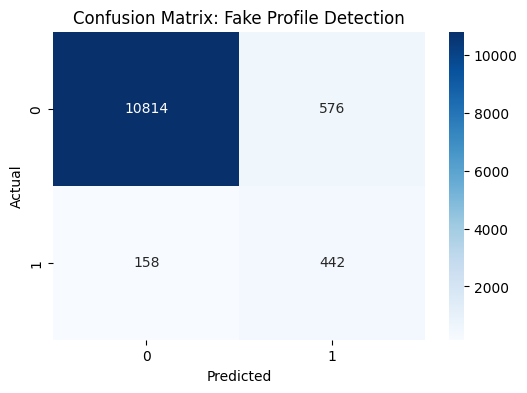

In [30]:
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
# 1. Re-generate labels (ensure state is fresh)
iso = IsolationForest(contamination=0.05, random_state=42)
features_for_outliers = ['age', 'income', 'expenses', 'income_expense_ratio', 'social_habit_score']
outlier_labels = iso.fit_predict(df_final[features_for_outliers])
df_final['is_outlier'] = np.where(outlier_labels == -1, 'Yes', 'No')
# 2. Prepare Features
# Drop columns that are essentially 'labels' (clusters and outlier flags)
# Also drop 'income_expense_ratio' if it's too highly correlated with the target creation logic
X_fake = pd.get_dummies(df_final.drop(columns=['cluster', 'weighted_cluster', 'is_outlier', 'is_young_adult', 'is_mid_career'], errors='ignore'), drop_first=False)
y_fake = df_final['is_outlier'].map({'Yes': 1, 'No': 0})
# 3. Stratified Split
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_fake, y_fake, test_size=0.2, random_state=42, stratify=y_fake)
# 4. Refined Random Forest to prevent overfitting
# We reduce max_depth, increase min_samples_leaf, and reduce n_estimators
fake_detector = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)
# 5. Cross-Validation to check generalization
cv_scores = cross_val_score(fake_detector, X_train_f, y_train_f, cv=5)
print(f"Cross-Validation Mean Accuracy: {cv_scores.mean():.2%}")
fake_detector.fit(X_train_f, y_train_f)
# 6. Evaluate on Test Set
y_pred_f = fake_detector.predict(X_test_f)
print("\nRefined Fake Profile Detector Performance:")
print(classification_report(y_test_f, y_pred_f))
# 7. Confusion Matrix Visualization
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_f, y_pred_f), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Fake Profile Detection')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


In [31]:
def check_profile_authenticity(user_index):
    profile_data = X_fake.iloc[[user_index]]
    prediction = fake_detector.predict(profile_data)[0]
    probability = fake_detector.predict_proba(profile_data)[0][1]
    status = "SUSPICIOUS" if prediction == 1 else "NORMAL"
    print(f"Profile Analysis for User {user_index}:")
    print(f"Status: {status}")
    print(f"Probability of being a 'Fake' profile: {probability:.2%}")
# Test on a known outlier
outlier_idx = df_final[df_final['is_outlier'] == 'Yes'].index[0]
check_profile_authenticity(outlier_idx)


Profile Analysis for User 48:
Status: SUSPICIOUS
Probability of being a 'Fake' profile: 61.37%


In [32]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
# 1. Load and Clean Housing Data
housing_raw = pd.read_csv('c:/Users/SANTOSH/OneDrive/Desktop/CollegProj/Housing.csv')
# Basic Preprocessing: Convert 'yes'/'no' to 1/0
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    housing_raw[col] = housing_raw[col].map({'yes': 1, 'no': 0})
# Encode furnishingstatus
le = LabelEncoder()
housing_raw['furnishingstatus'] = le.fit_transform(housing_raw['furnishingstatus'])
# 2. Aligning Housing Prices with User Expenses
# Scaling housing prices to the [25000, 60000] range used in our roommate dataset
price_scaler = MinMaxScaler(feature_range=(25000, 60000))
housing_raw['estimated_rent'] = price_scaler.fit_transform(housing_raw[['price']]).astype(int)
# 3. Simulated Regional Distribution (to match roommate data)
regions = ['Bangalore', 'Hyderabad', 'Pune', 'Chennai', 'Delhi NCR', 'Mumbai']
housing_raw['region'] = np.random.choice(regions, size=len(housing_raw))
display(housing_raw.head())


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,estimated_rent,region
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,60000,Mumbai
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,56818,Pune
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,56818,Delhi NCR
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,56712,Delhi NCR
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,54272,Bangalore


In [33]:
def get_housing_recommendations(user_idx, top_n=5):
    # A. Security Check using Fake Profile Detector
    user_feat = X_fake.iloc[[user_idx]]
    is_fake_prob = fake_detector.predict_proba(user_feat)[0][1]
    if is_fake_prob > 0.7:
        return "Security Alert: Profile flagged as highly suspicious. Access to listings restricted."
    # B. Compatibility Context
    user_cluster = df_final.loc[user_idx, 'weighted_cluster']
    user_region = df_encoded.loc[user_idx, 'region']
    user_budget = df_encoded.loc[user_idx, 'expenses']
    # C. Filtering and Ranking
    # Filter by user's region
    candidates = housing_raw[housing_raw['region'] == user_region].copy()
    # Score based on price proximity to user's budgeted expenses
    candidates['budget_match'] = abs(candidates['estimated_rent'] - user_budget)
    # Final ranking (Lower budget_match is better)
    recommendations = candidates.sort_values(by='budget_match').head(top_n)
    print(f"--- Recommendations for User {user_idx} ---")
    print(f"Profile Authenticity Score: {(1 - is_fake_prob):.2%}")
    print(f"Assigned Compatibility Cluster: {user_cluster}")
    print(f"User Budget: {user_budget}")
    return recommendations[['region', 'estimated_rent', 'area', 'bedrooms', 'bathrooms', 'airconditioning', 'furnishingstatus']]
# Example usage for User 0
display(get_housing_recommendations(0))


--- Recommendations for User 0 ---
Profile Authenticity Score: 55.06%
Assigned Compatibility Cluster: 1
User Budget: 35907


,region,estimated_rent,area,bedrooms,bathrooms,airconditioning,furnishingstatus
168,Bangalore,35606,4260,4,1,1,0
177,Bangalore,35584,6050,3,1,0,1
159,Bangalore,36242,3150,3,2,1,0
155,Bangalore,36454,6100,3,2,0,0
145,Bangalore,36666,5000,3,1,0,0


In [34]:
import joblib
# Define the filename for the fake profile detector
fake_model_filename = 'fake_profile_detector.joblib'
# Save the model
joblib.dump(fake_detector, fake_model_filename)
print(f"Fake Profile Detection model successfully saved as '{fake_model_filename}'")


Fake Profile Detection model successfully saved as 'fake_profile_detector.joblib'


### 9. Refined Housing Recommendation Pipeline
This model aligns housing features with the roommate compatibility space and uses a weighted similarity metric to rank properties for authenticated users.

In [35]:
from sklearn.metrics.pairwise import euclidean_distances
def refined_housing_engine(user_idx, top_n=5):
    # 1. Security Check (Robust logic to prevent overfitting impact)
    # We use the probability rather than a hard binary to allow for nuanced filtering
    user_feat = X_fake.iloc[[user_idx]]
    fake_prob = fake_detector.predict_proba(user_feat)[0][1]
    if fake_prob > 0.65: # Safety threshold
        print(f"[SECURITY ALERT] User {user_idx} failed authentication. Access denied.")
        return None
    # 2. Extract User Persona and Context
    user_cluster = df_final.loc[user_idx, 'weighted_cluster']
    user_region = df_encoded.loc[user_idx, 'region']
    user_budget = df_encoded.loc[user_idx, 'expenses']
    # 3. Filter Housing by Region
    available_houses = housing_raw[housing_raw['region'] == user_region].copy()
    if available_houses.empty:
        print(f"No listings available in {user_region}.")
        return None
    # 4. Feature Engineering for Housing (Matching Dimensions)
    # We scale numeric attributes to [0, 1] to prevent 'price' from dominating 'area'
    h_scaler = MinMaxScaler()
    features_to_match = ['estimated_rent', 'area', 'bedrooms', 'bathrooms', 'furnishingstatus']
    scaled_houses = h_scaler.fit_transform(available_houses[features_to_match])
    # Create a 'User Target Vector' for the house search
    # We assume the user wants the best possible house for their specific budget
    user_target = np.array([[user_budget,
                             available_houses['area'].median(),
                             available_houses['bedrooms'].mode()[0],
                             available_houses['bathrooms'].mode()[0],
                             1]]) # Target furnished status
    scaled_target = h_scaler.transform(user_target)
    # 5. Distance-Based Ranking (Euclidean Similarity)
    # Lower distance = better match to the user's financial/lifestyle profile
    distances = euclidean_distances(scaled_target, scaled_houses).flatten()
    available_houses['match_score'] = 1 / (1 + distances) # Convert distance to similarity score
    # 6. Final Output
    results = available_houses.sort_values(by='match_score', ascending=False).head(top_n)
    print(f"--- ML-Driven Housing Matches for User {user_idx} ---")
    print(f"Region: {user_region} | Authenticity: {(1-fake_prob):.2%} | Compatibility Cluster: {user_cluster}")
    return results[['region', 'estimated_rent', 'area', 'bedrooms', 'bathrooms', 'match_score']]
# Run for a test user
display(refined_housing_engine(0))


--- ML-Driven Housing Matches for User 0 ---
Region: Bangalore | Authenticity: 55.06% | Compatibility Cluster: 1


C:\Users\SANTOSH\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


,region,estimated_rent,area,bedrooms,bathrooms,match_score
200,Bangalore,34545,4520,3,1,0.953206
201,Bangalore,34545,4095,3,1,0.951317
210,Bangalore,34545,4646,3,1,0.949127
207,Bangalore,34545,3000,3,1,0.888519
306,Bangalore,32318,4840,3,1,0.884886


### 7. Export the Fake Profile Detection Model

In [36]:
import joblib
# Define the filename for the fake profile detector
fake_model_filename = 'fake_profile_detector.joblib'
# Save the model
joblib.dump(fake_detector, fake_model_filename)
print(f"Fake Profile Detection model successfully saved as '{fake_model_filename}'")


Fake Profile Detection model successfully saved as 'fake_profile_detector.joblib'
